In [40]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import radio_tools as rt
import astropy.units as u
from scipy.fft import next_fast_len

Now that we're familiar with fringes, let's actually compute the UV coverage for the array.
Remember that UV plane is defined in the direction of the source.

Supposed our baselines

In [7]:
hera = np.genfromtxt(
    "hera_ant_pos.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)
hera_xyz = np.asarray([hera['x'],hera['y'],hera['z']]).T.copy() # xyz along columns
hera_ref = EarthLocation.from_geodetic(lat='−30.72152612068925°', lon='21.42830382686301°',height='1051.69 m')
hera_enu = rt.itrs_to_enu(hera_xyz, hera_ref.lat.deg, hera_ref.lon.deg)
nant = hera_xyz.shape[0]
ix = np.triu_indices(nant,k=1)
hera_bl_enu = hera_enu[ix[1]]-hera_enu[ix[0]]

tstart = 1753200150 #random datetime, you can choose your favorite, just make sure the source is risen!
obstime=Time(tstart,format="unix",scale="utc")
cenA = SkyCoord(ra='13h 25m 27.6150s',dec='−43° 01′ 08.806″', frame='icrs') 
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))

In [18]:
# Let's say it's operating at 150 MHz, and each dish is 14 m wide.
# what's the FoV of one dish, and what's the rough resolution of the array?
nu=150e6
lm = 3e8/nu #m
d = 14 #m dish size
max_bl = np.max(np.sqrt(np.sum(hera_bl_enu**2,axis=1)))
res = lm/max_bl #max baseline
fov = lm/d

print(f"Synth. beam res\t: {np.rad2deg(res)*60:4.2f} arcmin\nFOV\t\t: {np.rad2deg(fov):4.2f} deg")

Synth. beam res	: 7.84 arcmin
FOV		: 8.19 deg


In [25]:
#Projecting baseline in ENU to uvw where w is along the source. I will build the change of basis matrix explicitly
sin_az = np.sin(azalt_cenA.az.rad)
cos_az = np.cos(azalt_cenA.az.rad)
sin_alt = np.sin(azalt_cenA.alt.rad)
cos_alt = np.cos(azalt_cenA.alt.rad)

# same trick as getting ENU from geocentric coordinates.
# But it's exact now because celestial sphere is indeed a sphere, unlike Earth.
# sin_az = 0
# cos_az = 1
# cos_alt = 0
# sin_alt = 1
W= [sin_az*cos_alt, cos_az*cos_alt, sin_alt] #components of w in ENU, this is the direction of the source!
U= [cos_az, -sin_az, 0] #east rotates by azimuth
V = np.cross(W,U)
# print(U,V,W)

mat = np.vstack([U,V,W]).T
hera_uvw = hera_bl_enu@mat/lm


Text(0, 0.5, 'V (wavelengths)')

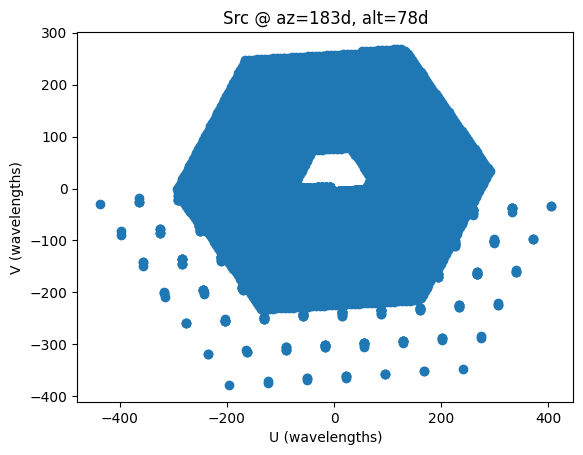

In [31]:
plt.scatter(hera_uvw[:,0], hera_uvw[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

We want to image. Want to grid UV coverage onto a regular FFT grid.

What grid spacing in uv?
What size of grid?

Remember time-domain examples. Frequency resolution is the 1/longest timescale you measure. And total extent (-ve to +ve) in frequency is the 1/smallest timescale you measure = sampling rate. Same idea but our fourier duals are pixels of the image on the sky and uv points on the UV plane.

Grid spacing $\Delta u$ set by the patch size we want to image ~ 1/full-width of primary beam.

Grid size $u_{max}$ set by the image resolution we want ~ 1/synthesized beam.

In [60]:
def grid_uv(uv,du,npix):
    
    S = np.zeros((npix,npix),dtype='float64')
    uv_int = np.round(uv/du).astype(int)
    for i in range(uv.shape[0]):
        S[uv_int[i,0],uv_int[i,1]] +=1
        #image is a real field. So it's FFT must be hermitian symmetric
        S[-uv_int[i,0],-uv_int[i,1]] +=1
    return S

In [66]:
du=1/fov
umax=1/res
npix = int(fov/res)
#it's generally better to over-sample the image to avoid pixelization effects. Rule of thumb is 3 pixels per beamwidth.
npix *= 3
img_res = res/3
gridded_uv = grid_uv(hera_uvw[:,:2], du, npix)

In [92]:
img = np.fft.ifft2(gridded_uv).real

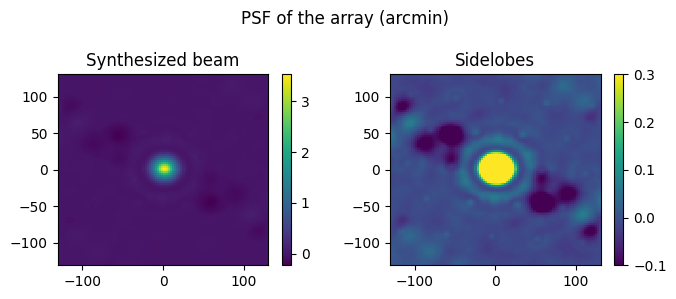

In [105]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("PSF of the array (arcmin)")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()

new az alt 222.11984250452292 5.53945633698941


Text(0, 0.5, 'V (wavelengths)')

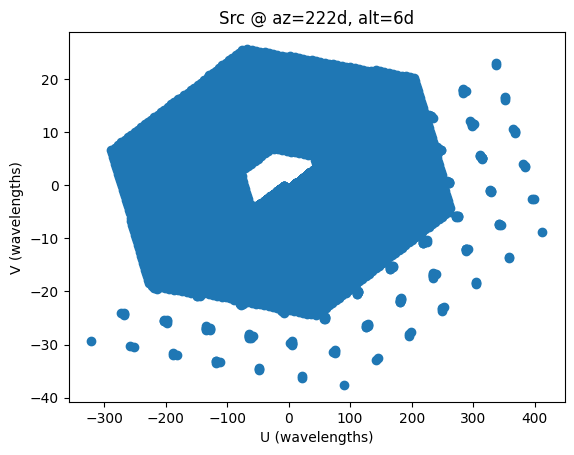

In [114]:
tstart = 1753200150 + 27000
obstime=Time(tstart,format="unix",scale="utc")
azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("new az alt", azalt_cenA.az.deg, azalt_cenA.alt.deg)
sin_az = np.sin(azalt_cenA.az.rad)
cos_az = np.cos(azalt_cenA.az.rad)
sin_alt = np.sin(azalt_cenA.alt.rad)
cos_alt = np.cos(azalt_cenA.alt.rad)
W= [sin_az*cos_alt, cos_az*cos_alt, sin_alt] #components of w in ENU, this is the direction of the source!
U= [cos_az, -sin_az, 0] #east rotates by azimuth
V = np.cross(W,U)
mat = np.vstack([U,V,W]).T
hera_uvw = hera_bl_enu@mat/lm
plt.scatter(hera_uvw[:,0], hera_uvw[:,1])
plt.title(f"Src @ az={azalt_cenA.az.deg:.0f}d, alt={azalt_cenA.alt.deg:.0f}d")
plt.xlabel("U (wavelengths)")
plt.ylabel("V (wavelengths)")

Severe baseline forshortening in NS direction because of how low the source is. Since it's at approx near local south (180 d azimuth), EW baseline isnt too affected. But given how low it is (6 d alt), projected NS baseline is very short.

In [115]:
gridded_uv = grid_uv(hera_uvw[:,:2], du, npix)
img = np.fft.ifft2(gridded_uv).real

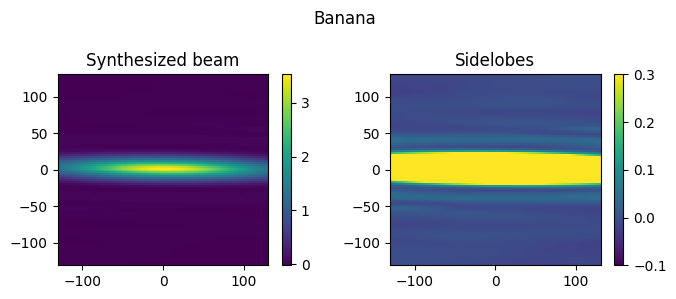

In [116]:
width=50 #pix
patch=slice(npix//2-width,npix//2+width)
extent = [-np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60, -np.rad2deg(width*img_res)*60, np.rad2deg(width*img_res)*60]
f=plt.gcf()
plt.suptitle("Banana")
f.set_size_inches(7,3)
plt.subplot(121)
plt.title("Synthesized beam")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.subplot(122)
plt.title("Sidelobes")
im=plt.imshow(np.fft.fftshift(img)[patch,patch],aspect='auto',interpolation='none',vmax=0.3,vmin=-0.1,origin='lower',extent=extent)
plt.colorbar(ax=plt.gca())
plt.tight_layout()